<a href="https://colab.research.google.com/github/GenerationBR/ETL_Healthcare/blob/main/HEALTHCARE_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ETL

In [ ]:
# importando um repositório do github
!git clone https://github.com/ChiaviniK/healthcare

Cloning into 'healthcare'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), 2.88 MiB | 8.30 MiB/s, done.


In [ ]:
# Transformando as informações de dados
# Fazer o python ler os dados
import pandas as pd

df_healthcare = pd.read_csv('/content/healthcare/healthcare_dataset.csv')
print('Informações base do csv')
df_healthcare.info()
display(df_healthcare.head(3))

Informações base do csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), obje

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal


In [ ]:
# transformando dados
df_healthcare['Name'] = df_healthcare['Name'].str.title()
# aqui nós arrumanos para modo de título, sempre a primeira letra maiscula

# fazendo datas serem datas
df_healthcare['Date of Admission'] = pd.to_datetime(df_healthcare['Date of Admission'])
df_healthcare['Discharge Date'] = pd.to_datetime(df_healthcare['Discharge Date'])

# Ainda pensando em data - coluna nova chamada de tempo de internação - Days Hospitalized
df_healthcare['Days Hospitalized'] = (df_healthcare['Discharge Date']-df_healthcare['Date of Admission']).dt.days

# arredondando os valores
df_healthcare['Billing Amount'] = df_healthcare['Billing Amount'].round(2)

# para remover erros ocultos na sua base de dados
# um dado duplicado, por exemplo
df_healthcare = df_healthcare.drop_duplicates()

In [ ]:
# Carregar os dados
df_healthcare.to_csv('healthcare_clean.csv', index=False)

# Estatisticas

In [ ]:
# dados estatisticos do arquivo
# estatistica descritiva
# aqui vai apresentar todos os dados númericos, e a contagem deles acima.
display(df_healthcare.describe().round(2))
print('-----Estatistica por categoria-----')
# aqui, apresentam todos os textos.
display(df_healthcare.describe(include=['O', 'object']))

print('Estatistica por condição Médica')
display(df_healthcare['Medical Condition'].value_counts())
print('Estatistica por tipo sanguineo')
display(df_healthcare['Blood Type'].value_counts())

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date,Days Hospitalized
count,54966.00,54966,54966.00,54966.00,54966,54966.00
mean,51.54,2021-11-01 17:35:29.505512448,25544.31,301.12,2021-11-17 05:34:28.202161408,15.50
min,13.00,2019-05-08 00:00:00,-2008.49,101.00,2019-05-09 00:00:00,1.00
25%,35.00,2020-07-28 00:00:00,13243.72,202.00,2020-08-13 00:00:00,8.00
50%,52.00,2021-11-02 00:00:00,25542.75,302.00,2021-11-18 00:00:00,15.00
75%,68.00,2023-02-03 00:00:00,37819.86,401.00,2023-02-19 00:00:00,23.00
max,89.00,2024-05-07 00:00:00,52764.28,500.00,2024-06-06 00:00:00,30.00
std,19.61,NaN,14208.41,115.22,NaN,8.66


-----Estatistica por categoria-----


,Name,Gender,Blood Type,Medical Condition,Doctor,Hospital,Insurance Provider,Admission Type,Medication,Test Results
count,54966,54966,54966,54966,54966,54966,54966,54966,54966,54966
unique,40235,2,8,6,40341,39876,5,3,5,3
top,Michael Williams,Male,A-,Arthritis,Michael Smith,LLC Smith,Cigna,Elective,Lipitor,Abnormal
freq,24,27496,6898,9218,27,44,11139,18473,11038,18437


Estatistica por condição Médica


,count
Medical Condition,
Arthritis,9218
Diabetes,9216
Hypertension,9151
Obesity,9146
Cancer,9140
Asthma,9095


Estatistica por tipo sanguineo


,count
Blood Type,
A-,6898
A+,6896
B+,6885
AB+,6882
AB-,6874
B-,6872
O+,6855
O-,6804


<Axes: xlabel='Medical Condition', ylabel='count'>

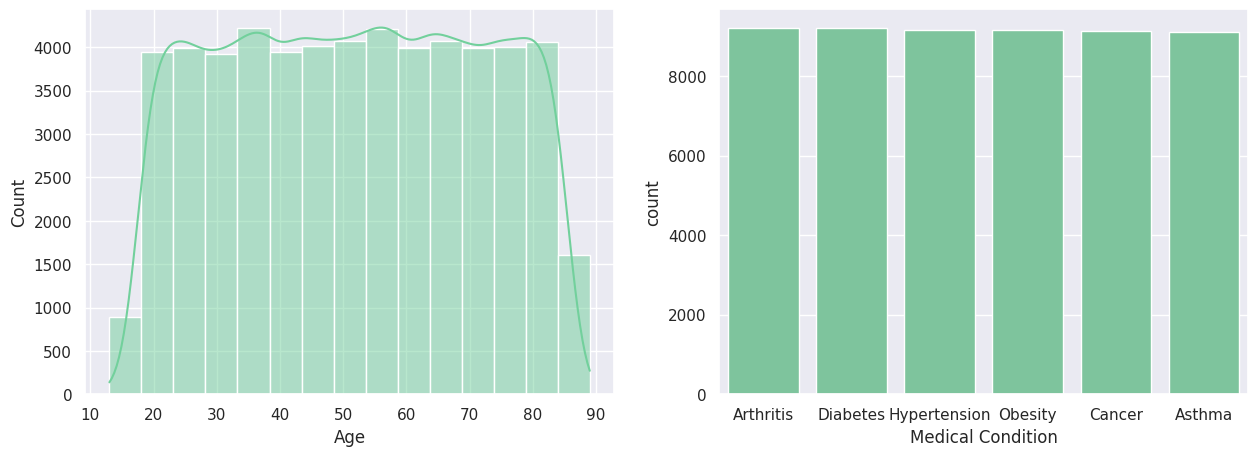

In [ ]:
# graficos
import matplotlib.pyplot as plt
import seaborn as sns

# configurar o estilo dos graficos
sns.set_theme(style='darkgrid')
plt.figure(figsize=(15,5))

# podemos criar subplots
plt.subplot(1,2,1)
# bins = distribuição, detalhamento; kde=kind
sns.histplot(df_healthcare['Age'], bins=15, kde=True, color='#72D09C')

plt.subplot(1,2,2)
sns.countplot(data=df_healthcare,
              x='Medical Condition',
              order=df_healthcare['Medical Condition'].value_counts().index,
              color='#72D09C')
